# Previsão de Inadimplência Bancária via Regressão Logística

**Disciplina:** Otimização Não-Linear 
**Professor:** Felipe Garcia 
**Integrantes:** Gabriel Negreiros Saraiva, Júlia Moraes da Silva, Luiz Eduardo de Almeida Siqueira Silva, Paulo Victor Cordeiro Rufino de Araújo, Pedro Lucas Simões Cabral

---

## 1. Objetivo

Implementar um classificador de **Regressão Logística** para prever inadimplência bancária, formulando o treinamento como um **problema de otimização** em aprendizado supervisionado de classificação.

$$\min_{\theta} \; L(\theta) = -\sum_{i=1}^{n} \left[ y_i \log \hat{y}_i + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

onde $\hat{y}_i = \sigma(x_i^\top \theta)$ e $\sigma(z) = \frac{1}{1 + e^{-z}}$.

Serão comparados dois algoritmos de otimização:
- **Gradiente Descendente** com busca em linha
- **Método de Newton** com busca em linha

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

---
## 2. Carregamento e Pré-processamento dos Dados

Dataset: **Credito** — 10.128 clientes, 15 features financeiras e comportamentais, rótulo binário de inadimplência.

In [2]:
df = pd.read_csv('../ONL/dados/credito.csv', na_values=['na', '','NaN','NA','NAN'])

In [3]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# 2. Corrigir colunas numéricas com formato BR (ponto=milhar, vírgula=decimal)
df['limite_credito'] = (df['limite_credito']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float))

df['valor_transacoes_12m'] = (df['valor_transacoes_12m']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float))

# 3. Remover coluna id (não agrega ao modelo)
df = df.drop(columns=['id'])

# 4. Separar X e y
X = df.drop(columns=['default'])
y = df['default']

# 5. One Hot Encoding (drop_first=True para evitar multicolinearidade)
colunas_categoricas = ['sexo', 'escolaridade', 'estado_civil', 'salario_anual', 'tipo_cartao']
X = pd.get_dummies(X, columns=colunas_categoricas, drop_first=True)

# 6. Split treino/teste (stratify mantém proporção de inadimplentes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Escalar features numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [4]:
X.columns

Index(['idade', 'dependentes', 'meses_de_relacionamento', 'qtd_produtos',
       'iteracoes_12m', 'meses_inativo_12m', 'limite_credito',
       'valor_transacoes_12m', 'qtd_transacoes_12m', 'sexo_M',
       'escolaridade_ensino medio', 'escolaridade_graduacao',
       'escolaridade_mestrado', 'escolaridade_sem educacao formal',
       'estado_civil_divorciado', 'estado_civil_solteiro',
       'salario_anual_$40K - $60K', 'salario_anual_$60K - $80K',
       'salario_anual_$80K - $120K', 'salario_anual_menos que $40K',
       'tipo_cartao_gold', 'tipo_cartao_platinum', 'tipo_cartao_silver'],
      dtype='object')

---
## 3. Formulação Matemática

### Modelo

Dado $X \in \mathbb{R}^{n \times (p+1)}$ (com coluna de bias), $y \in \{0,1\}^n$, $\theta \in \mathbb{R}^{p+1}$:

$$\hat{y}_i = \sigma(x_i^\top \theta), \quad \sigma(z) = \frac{1}{1 + e^{-z}}$$

### Função de Perda (a minimizar)

$$L(\theta) = -\sum_{i=1}^{n} \left[ y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i) \right]$$

### Gradiente

$$\nabla L(\theta) = X^\top(\hat{y} - y)$$

### Hessiana

$$H(\theta) = X^\top W X, \quad W = \mathrm{diag}\!\left(\hat{y}_i(1-\hat{y}_i)\right)$$

A Hessiana é **positiva semi-definida** → $L(\theta)$ é **convexa** → qualquer mínimo local é global.

---
## 3.1 Gradiente, Hessiana e Prova de Convexidade

### Prova: H(θ) é Positiva Semi-Definida

A Hessiana da função de perda (sem regularização) é:

$$H(\theta) = \frac{1}{n} X^\top W X, \qquad W = \mathrm{diag}\!\left(\hat{y}_i(1-\hat{y}_i)\right)$$

**Prova algébrica** — Para qualquer $v \in \mathbb{R}^{p+1}$:

$$v^\top H v = \frac{1}{n}\, v^\top X^\top W X v = \frac{1}{n}\,(Xv)^\top W (Xv) = \frac{1}{n}\sum_{i=1}^{n} w_i\,(x_i^\top v)^2$$

Como $\sigma(z) \in (0,1)$ para todo $z$ real, cada peso satisfaz:

$$w_i = \hat{y}_i(1 - \hat{y}_i) \in \left(0,\, \tfrac{1}{4}\right]$$

Logo cada termo $w_i\,(x_i^\top v)^2 \geq 0$, e portanto:

$$\boxed{v^\top H v \geq 0 \quad \forall\, v \quad \Longrightarrow \quad H(\theta) \succeq 0 \quad \forall\, \theta}$$

> **Com regularização L2** ($\lambda > 0$): a implementação usa $H_{\text{reg}} = H + \lambda\,\mathrm{diag}(0, 1, \ldots, 1)$, que adiciona $\lambda > 0$ a todos os autovalores (exceto o do bias). Isso torna $H_{\text{reg}}$ **estritamente positiva definida** ($H \succ 0$), garantindo unicidade do mínimo e estabilidade numérica ao resolver $H\,d = -\nabla L$ no Método de Newton.

In [5]:
from regressao_log import RegressaoLogistica

# Preparar dados: converter para numpy e adicionar coluna de bias
X_np = np.array(X_train, dtype=float)
y_np = np.array(y_train, dtype=float)
X_b  = np.c_[np.ones(X_np.shape[0]), X_np]   # (n, p+1)

theta_0 = np.zeros(X_b.shape[1])
lambda_ = 0.01

# ---------- Gradiente em θ₀ = 0 ----------
grad_0 = RegressaoLogistica._gradiente(theta_0, X_b, y_np, lambda_)

# ---------- Hessiana em θ₀ = 0 ----------
H_0 = RegressaoLogistica._hessiana(theta_0, X_b, lambda_)

# ---------- Autovalores (eigvalsh para matrizes simétricas) ----------
autovalores = np.linalg.eigvalsh(H_0)

print(f"Dimensão de H(θ₀):            {H_0.shape}")
print(f"‖∇L(θ₀)‖:                     {np.linalg.norm(grad_0):.4f}")
print(f"Autovalor mínimo λ_min:        {autovalores.min():.8f}  "
      f"{'≥ 0  →  PSD ✓' if autovalores.min() >= -1e-10 else '< 0  ✗'}")
print(f"Autovalor máximo λ_max:        {autovalores.max():.4f}")
print(f"Número de condição κ(H):       {autovalores.max() / max(autovalores.min(), 1e-12):.1f}")
print(f"\nTodos autovalores ≥ 0?        {'Sim ✓' if (autovalores >= -1e-10).all() else 'Não ✗'}")

Dimensão de H(θ₀):            (24, 24)
‖∇L(θ₀)‖:                     3442.9483
Autovalor mínimo λ_min:        0.00294004  ≥ 0  →  PSD ✓
Autovalor máximo λ_max:        42136641.5920
Número de condição κ(H):       14331987083.8

Todos autovalores ≥ 0?        Sim ✓


In [6]:
nomes_features = ["bias"] + list(X_train.columns)

### O que implica H(θ) ⪰ 0?

#### 1. L(θ) é convexa

Uma função diferenciável é convexa se e somente se sua Hessiana é positiva semi-definida em todo o domínio. Como $H(\theta) \succeq 0$ para **qualquer** $\theta$ (os pesos $w_i = \hat{y}_i(1-\hat{y}_i)$ dependem de $\theta$, mas sempre $w_i > 0$), a função de perda de entropia cruzada é **globalmente convexa**.

**Consequência prática:** qualquer mínimo local é automaticamente um mínimo global. O algoritmo de otimização não pode ficar preso em ótimos locais — qualquer convergência é para a solução ótima.

#### 2. O Método de Newton é garantidamente uma direção de descida

A direção de Newton $d_k = -H(\theta_k)^{-1} \nabla L(\theta_k)$ é uma **direção de descida** sempre que $H \succ 0$:

$$\nabla L^\top d_k = -\nabla L^\top H^{-1} \nabla L < 0$$

pois $H^{-1} \succ 0$ quando $H \succ 0$. Isso garante que cada passo de Newton reduz $L(\theta)$.

#### 3. O número de condição κ(H) governa a velocidade do GD

O Gradiente Descendente converge em $O(\kappa(H))$ iterações no pior caso, onde:

$$\kappa(H) = \frac{\lambda_{\max}}{\lambda_{\min}}$$

Um $\kappa$ alto significa que existem direções com curvaturas muito diferentes — o GD "ziguezagueia" entre elas. O Método de Newton usa $H^{-1}$ para normalizar essas curvaturas, sendo **invariante ao condicionamento** de $H$ e convergindo em $O(\log(1/\varepsilon))$ iterações independentemente de $\kappa$.

---
## 4. Demonstração das Funções do Modelo

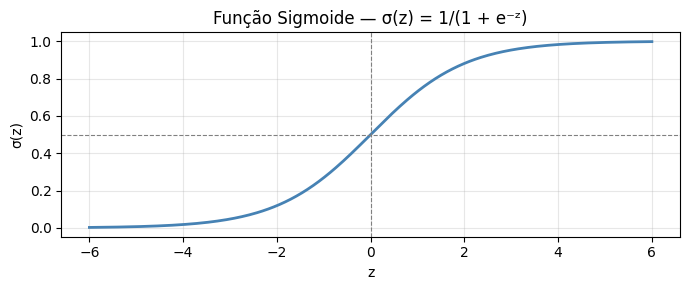

Perda inicial L(0):          0.69
‖∇L(0)‖:                     3442.95
Autovalor mínimo H(0):       0.0029  (≥ 0 → convexa ✓)
Autovalor máximo H(0):       42136641.5920
Número de condição H(0):     14331987083.8


In [7]:
# Sigmoide
z = np.linspace(-6, 6, 300)
plt.figure(figsize=(7, 3))
plt.plot(z, RegressaoLogistica._sigmoide(z), color='steelblue', linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0,   color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('z'); plt.ylabel('σ(z)')
plt.title('Função Sigmoide — σ(z) = 1/(1 + e⁻ᶻ)')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Perda, gradiente e hessiana no ponto inicial (usando variáveis da seção 3.1)
perda_0 = RegressaoLogistica._funcao_perda(theta_0, X_b, y_np, lambda_)

print(f"Perda inicial L(0):          {perda_0:.2f}")
print(f"‖∇L(0)‖:                     {np.linalg.norm(grad_0):.2f}")
print(f"Autovalor mínimo H(0):       {autovalores.min():.4f}  (≥ 0 → convexa ✓)")
print(f"Autovalor máximo H(0):       {autovalores.max():.4f}")
print(f"Número de condição H(0):     {autovalores.max()/autovalores.min():.1f}")

---
## 5. Métodos de Busca em Linha — Demonstração 1D

Aplicamos cada método à função $f(\alpha) = 2\alpha^2 - 7\alpha + 1$, cujo mínimo exato é $\alpha^* = 7/4 = 1{,}75$.

intervalo_inicial:          [0.6400, 2.5600]
busca_secao_aurea:          α* = 1.75000000  (erro = 2.82e-10)
busca_particao_igual:       α* = 1.75000018  (erro = 1.79e-07)
busca_ajuste_quadratico:    α* = 1.75000000  (erro = 6.66e-16)


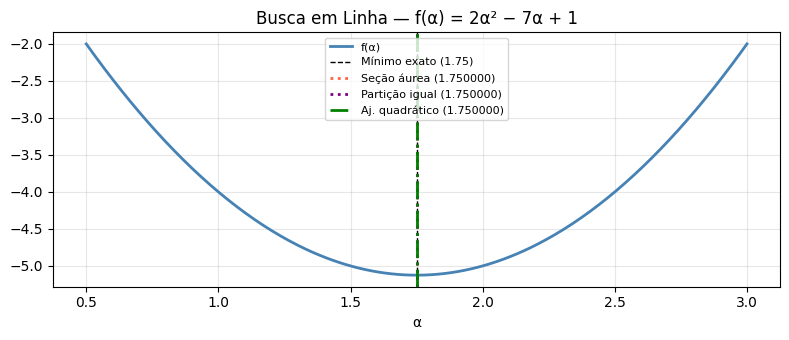

In [8]:
f = lambda a: 2*a**2 - 7*a + 1
alpha_exato = 1.75

# Intervalo inicial automático
a0, b0 = RegressaoLogistica._intervalo_inicial(f)
print(f"intervalo_inicial:          [{a0:.4f}, {b0:.4f}]")

# Seção áurea
alpha_aurea = RegressaoLogistica._busca_secao_aurea(f, a0, b0, n_iter=50)
print(f"busca_secao_aurea:          α* = {alpha_aurea:.8f}  (erro = {abs(alpha_aurea-alpha_exato):.2e})")

# Partição igual (trisseção)
alpha_part = RegressaoLogistica._busca_particao_igual(f, a0, b0, tol=1e-6)
print(f"busca_particao_igual:       α* = {alpha_part:.8f}  (erro = {abs(alpha_part-alpha_exato):.2e})")

# Ajuste quadrático
alpha_quad = RegressaoLogistica._busca_ajuste_quadratico(f, a0, b0, n_iter=50)
print(f"busca_ajuste_quadratico:    α* = {alpha_quad:.8f}  (erro = {abs(alpha_quad-alpha_exato):.2e})")

# Visualização
alpha_vals = np.linspace(0.5, 3.0, 300)
plt.figure(figsize=(8, 3.5))
plt.plot(alpha_vals, f(alpha_vals), color='steelblue', linewidth=2, label='f(α)')
plt.axvline(alpha_exato,  color='black',  linestyle='--', linewidth=1, label=f'Mínimo exato ({alpha_exato})')
plt.axvline(alpha_aurea,  color='tomato', linestyle=':',  linewidth=2, label=f'Seção áurea ({alpha_aurea:.6f})')
plt.axvline(alpha_part,   color='purple', linestyle=':',  linewidth=2, label=f'Partição igual ({alpha_part:.6f})')
plt.axvline(alpha_quad,   color='green',  linestyle='-.',  linewidth=2, label=f'Aj. quadrático ({alpha_quad:.6f})')
plt.xlabel('α'); plt.title('Busca em Linha — f(α) = 2α² − 7α + 1')
plt.legend(fontsize=8); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

---
## 6. Treinamento — Gradiente Descendente com Busca em Linha

$$\theta_{k+1} = \theta_k - \alpha^* \nabla L(\theta_k), \quad \alpha^* = \arg\min_\alpha L(\theta_k - \alpha \nabla L(\theta_k))$$

**Nota:** O GD tem convergência **linear** — a norma do gradiente decresce ~0.5% por iteração perto do ótimo. Com 24.000 amostras, atingir $\|\nabla L\| < 10^{-4}$ requer ~7.800 iterações. Aqui executamos 500 iterações para demonstrar a trajetória de convergência.

Executando Gradiente Descendente (500 iterações)...
Iterações executadas:  500
Perda inicial → final: 0.69 → 0.42
‖∇L‖ inicial → final:  3442.95 → 6.5235
Tempo de execução:     10.8s


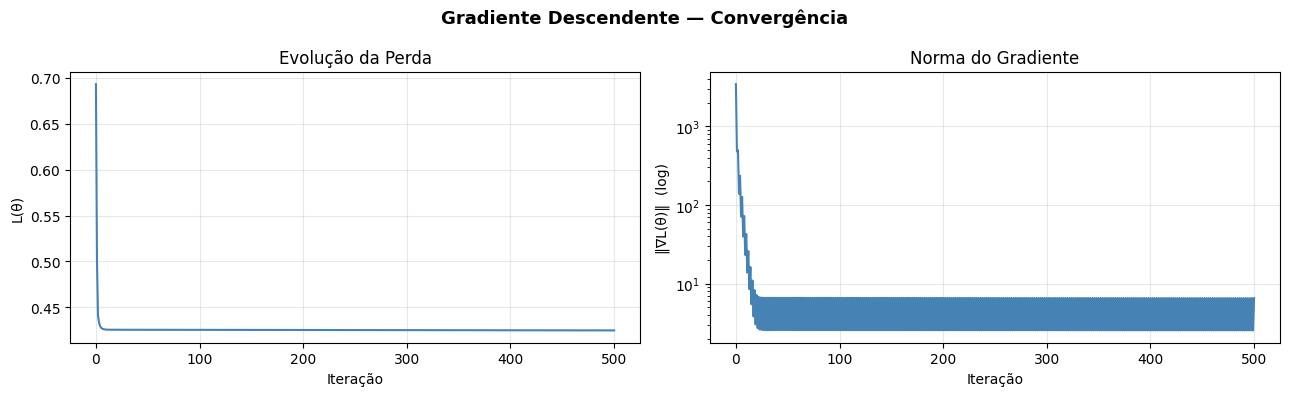

In [9]:
import time

# Criar modelo com Gradiente Descendente
modelo_gd = RegressaoLogistica(
    metodo_otimizacao='gradiente_descendente',
    metodo_busca='secao_aurea',
    tmax=500,
    tolerancia=1e-4,
    lambda_=0.01
)

print("Executando Gradiente Descendente (500 iterações)...")
t_inicio_gd = time.time()
modelo_gd.fit(X_train, y_train)
tempo_gd = time.time() - t_inicio_gd

print(f"Iterações executadas:  {modelo_gd.n_iteracoes_}")
print(f"Perda inicial → final: {modelo_gd.historico_perda_[0]:.2f} → {modelo_gd.historico_perda_[-1]:.2f}")
print(f"‖∇L‖ inicial → final:  {modelo_gd.historico_norma_grad_[0]:.2f} → {modelo_gd.historico_norma_grad_[-1]:.4f}")
print(f"Tempo de execução:     {tempo_gd:.1f}s")

# Gráfico de convergência
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(modelo_gd.historico_perda_, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('Iteração')
axes[0].set_ylabel('L(θ)')
axes[0].set_title('Evolução da Perda')
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(modelo_gd.historico_norma_grad_, color='steelblue', linewidth=1.5)
axes[1].set_xlabel('Iteração')
axes[1].set_ylabel('‖∇L(θ)‖  (log)')
axes[1].set_title('Norma do Gradiente')
axes[1].grid(True, alpha=0.3)

fig.suptitle('Gradiente Descendente — Convergência', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Treinamento — Método de Newton com Busca em Linha

$$\theta_{k+1} = \theta_k + \alpha^* d_k, \quad d_k = -H(\theta_k)^{-1}\nabla L(\theta_k)$$

A direção de Newton incorpora a **curvatura** da função via Hessiana, resultando em convergência **quadrática** — a precisão dobra a cada iteração perto do ótimo.

Executando Método de Newton...
Iterações para convergência: 4
Perda inicial → final:       0.69 → 0.29
‖∇L‖ inicial → final:        3442.95 → 7.76e-06
Tempo de execução:           0.12s


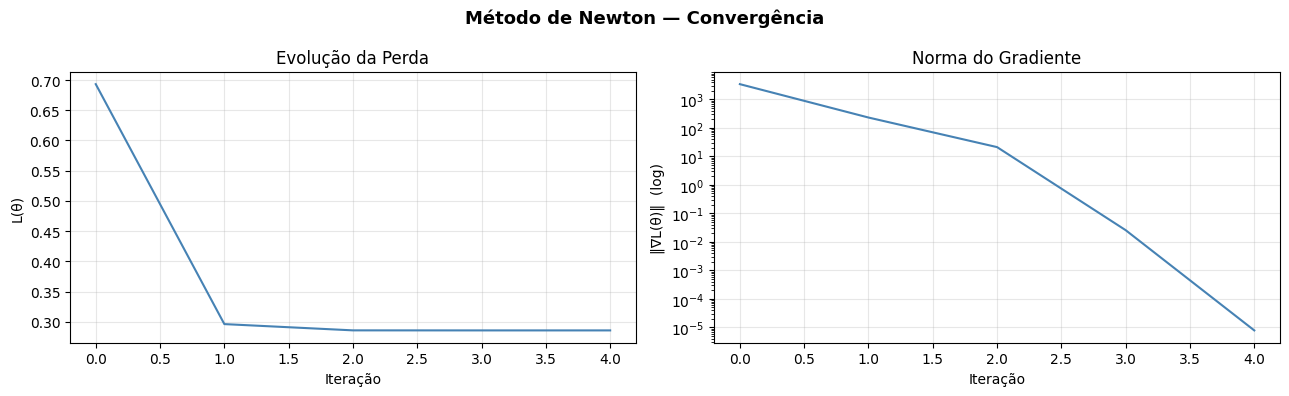

In [10]:
# Criar modelo com Método de Newton
modelo_newton = RegressaoLogistica(
    metodo_otimizacao='newton',
    metodo_busca='secao_aurea',
    tmax=100,
    tolerancia=1e-4,
    lambda_=0.01
)

print("Executando Método de Newton...")
t_inicio_nt = time.time()
modelo_newton.fit(X_train, y_train)
tempo_newton = time.time() - t_inicio_nt

print(f"Iterações para convergência: {modelo_newton.n_iteracoes_}")
print(f"Perda inicial → final:       {modelo_newton.historico_perda_[0]:.2f} → {modelo_newton.historico_perda_[-1]:.2f}")
print(f"‖∇L‖ inicial → final:        {modelo_newton.historico_norma_grad_[0]:.2f} → {modelo_newton.historico_norma_grad_[-1]:.2e}")
print(f"Tempo de execução:           {tempo_newton:.2f}s")

# Gráfico de convergência
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(modelo_newton.historico_perda_, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('Iteração')
axes[0].set_ylabel('L(θ)')
axes[0].set_title('Evolução da Perda')
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(modelo_newton.historico_norma_grad_, color='steelblue', linewidth=1.5)
axes[1].set_xlabel('Iteração')
axes[1].set_ylabel('‖∇L(θ)‖  (log)')
axes[1].set_title('Norma do Gradiente')
axes[1].grid(True, alpha=0.3)

fig.suptitle('Método de Newton — Convergência', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Comparação dos Métodos de Otimização

Métrica                        GD (500 iters)       Newton
Iterações executadas                    500            4
Tempo de execução (s)                  10.8         0.12
Perda final L(θ)                     0.4248       0.2857
‖∇L(θ)‖ final                        6.5235     7.76e-06

Newton é ~125× mais eficiente em iterações
Newton é ~93× mais rápido em tempo de parede


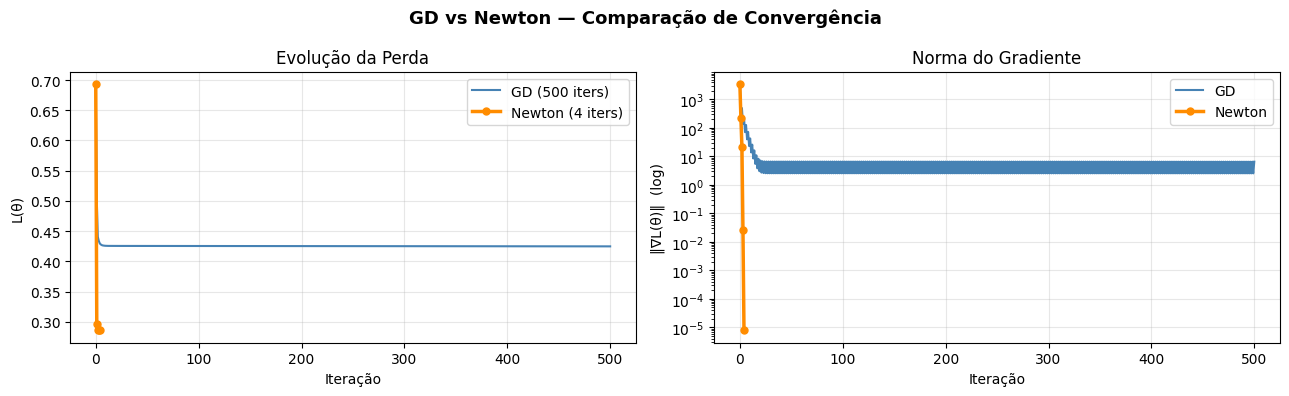

In [11]:
# --- Tabela comparativa ---
print("=" * 58)
print(f"{'Métrica':<30} {'GD (500 iters)':>12} {'Newton':>12}")
print("=" * 58)
print(f"{'Iterações executadas':<30} {modelo_gd.n_iteracoes_:>12d} {modelo_newton.n_iteracoes_:>12d}")
print(f"{'Tempo de execução (s)':<30} {tempo_gd:>12.1f} {tempo_newton:>12.2f}")
print(f"{'Perda final L(θ)':<30} {modelo_gd.historico_perda_[-1]:>12.4f} {modelo_newton.historico_perda_[-1]:>12.4f}")
print(f"{'‖∇L(θ)‖ final':<30} {modelo_gd.historico_norma_grad_[-1]:>12.4f} {modelo_newton.historico_norma_grad_[-1]:>12.2e}")
print("=" * 58)
print(f"\nNewton é ~{modelo_gd.n_iteracoes_/max(modelo_newton.n_iteracoes_,1):.0f}× mais eficiente em iterações")
print(f"Newton é ~{tempo_gd/max(tempo_newton,0.01):.0f}× mais rápido em tempo de parede")

# --- Curvas de convergência lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Perda
axes[0].plot(modelo_gd.historico_perda_, color='steelblue', linewidth=1.5,
             label=f'GD ({modelo_gd.n_iteracoes_} iters)')
axes[0].plot(modelo_newton.historico_perda_, color='darkorange', linewidth=2.5,
             label=f'Newton ({modelo_newton.n_iteracoes_} iters)', marker='o', markersize=5)
axes[0].set_xlabel('Iteração')
axes[0].set_ylabel('L(θ)')
axes[0].set_title('Evolução da Perda')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Norma do gradiente (log)
axes[1].semilogy(modelo_gd.historico_norma_grad_, color='steelblue', linewidth=1.5, label='GD')
axes[1].semilogy(modelo_newton.historico_norma_grad_, color='darkorange', linewidth=2.5,
                 label='Newton', marker='o', markersize=5)
axes[1].set_xlabel('Iteração')
axes[1].set_ylabel('‖∇L(θ)‖  (log)')
axes[1].set_title('Norma do Gradiente')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('GD vs Newton — Comparação de Convergência', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8.1 Comparação dos Métodos de Busca em Linha

Treinamos o Gradiente Descendente com cada um dos 3 métodos de busca disponíveis para comparar eficiência.

Seção Áurea            — 200 iters, perda final: 0.4252, tempo: 4.06s
Partição Igual         — 200 iters, perda final: 0.5698, tempo: 3.89s
Ajuste Quadrático      — 200 iters, perda final: 5.5649, tempo: 3.84s


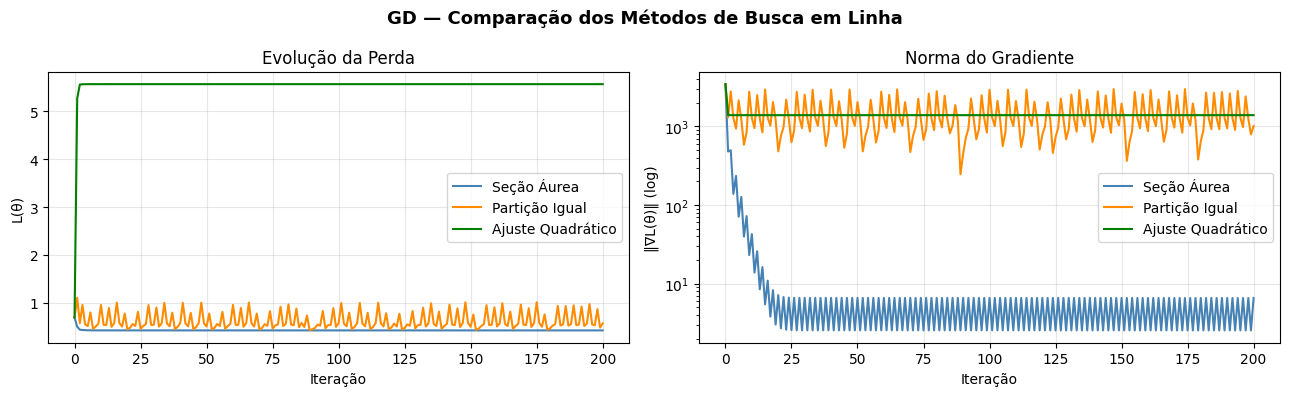

In [12]:
metodos_busca = ['secao_aurea', 'particao_igual', 'ajuste_quadratico']
nomes_busca   = ['Seção Áurea', 'Partição Igual', 'Ajuste Quadrático']
cores_busca   = ['steelblue', 'darkorange', 'green']
resultados_busca = {}

for metodo, nome in zip(metodos_busca, nomes_busca):
    modelo = RegressaoLogistica(
        metodo_otimizacao='gradiente_descendente',
        metodo_busca=metodo, tmax=200, tolerancia=1e-4, lambda_=0.01
    )
    t0 = time.time()
    modelo.fit(X_train, y_train)
    t1 = time.time()
    resultados_busca[nome] = {
        'modelo': modelo, 'tempo': t1 - t0
    }
    print(f"{nome:<22} — {modelo.n_iteracoes_} iters, "
          f"perda final: {modelo.historico_perda_[-1]:.4f}, tempo: {t1-t0:.2f}s")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for (nome, res), cor in zip(resultados_busca.items(), cores_busca):
    m = res['modelo']
    axes[0].plot(m.historico_perda_, color=cor, linewidth=1.5, label=nome)
    axes[1].semilogy(m.historico_norma_grad_, color=cor, linewidth=1.5, label=nome)

axes[0].set_xlabel('Iteração'); axes[0].set_ylabel('L(θ)')
axes[0].set_title('Evolução da Perda'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Iteração'); axes[1].set_ylabel('‖∇L(θ)‖ (log)')
axes[1].set_title('Norma do Gradiente'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
fig.suptitle('GD — Comparação dos Métodos de Busca em Linha', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 8.2 Número de Condição e Taxa de Convergência

O número de condição $\kappa(H) = \lambda_{\max}/\lambda_{\min}$ governa a velocidade do GD. Acompanhamos $\kappa$ ao longo das iterações do Newton para mostrar como a curvatura muda conforme o modelo converge.

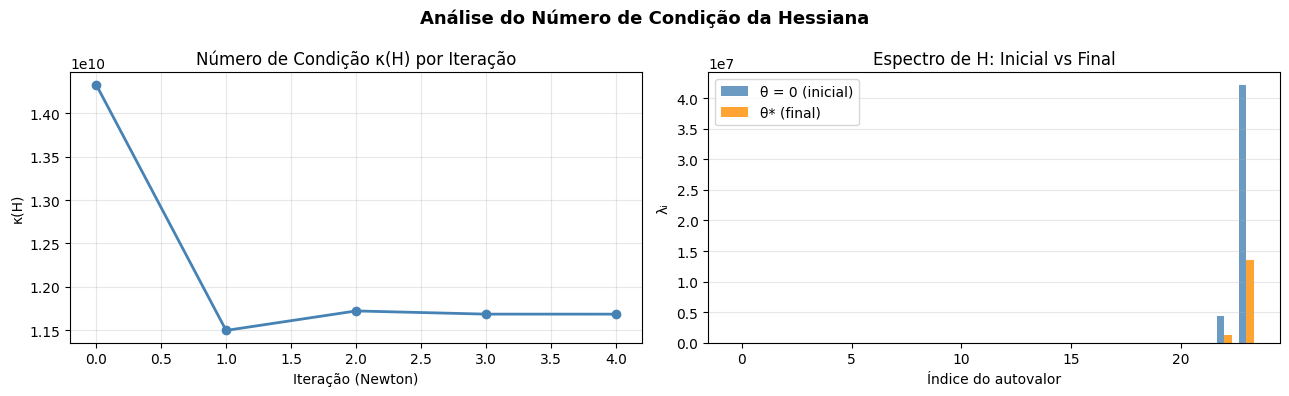

κ inicial: 14331987083.8
κ final:   11683133253.0


In [13]:
# Recalcular Hessiana em alguns pontos ao longo do treinamento do Newton
# para ver como κ(H) evolui
X_b_full = np.c_[np.ones(np.array(X_train).shape[0]), np.array(X_train, dtype=float)]
w_teste = np.zeros(X_b_full.shape[1])
y_np_full = np.array(y_train, dtype=float)

# Simular Newton manualmente para coletar κ a cada iteração
kappas = []
w = w_teste.copy()
for _ in range(modelo_newton.n_iteracoes_ + 1):
    H = RegressaoLogistica._hessiana(w, X_b_full, 0.01)
    avs = np.linalg.eigvalsh(H)
    kappas.append(avs.max() / max(avs.min(), 1e-12))
    # dar um passo de Newton
    grad = RegressaoLogistica._gradiente(w, X_b_full, y_np_full, 0.01)
    if np.linalg.norm(grad) < 1e-6:
        break
    H_reg = H + 1e-8 * np.eye(H.shape[0])
    d = np.linalg.solve(H_reg, -grad)
    g = lambda a: RegressaoLogistica._funcao_perda(w + a * d, X_b_full, y_np_full, 0.01)
    a0_, b0_ = RegressaoLogistica._intervalo_inicial(g)
    alpha = RegressaoLogistica._busca_secao_aurea(g, a0_, b0_)
    w = w + alpha * d

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# κ ao longo das iterações
axes[0].plot(range(len(kappas)), kappas, color='steelblue', linewidth=2, marker='o', markersize=6)
axes[0].set_xlabel('Iteração (Newton)')
axes[0].set_ylabel('κ(H)')
axes[0].set_title('Número de Condição κ(H) por Iteração')
axes[0].grid(True, alpha=0.3)

# Espectro final vs inicial
H_final = RegressaoLogistica._hessiana(w, X_b_full, 0.01)
avs_final = np.linalg.eigvalsh(H_final)
avs_inicial = np.linalg.eigvalsh(RegressaoLogistica._hessiana(w_teste, X_b_full, 0.01))

x_pos = np.arange(len(avs_final))
largura = 0.35
axes[1].bar(x_pos - largura/2, avs_inicial, largura, color='steelblue', label='θ = 0 (inicial)', alpha=0.8)
axes[1].bar(x_pos + largura/2, avs_final, largura, color='darkorange', label='θ* (final)', alpha=0.8)
axes[1].set_xlabel('Índice do autovalor')
axes[1].set_ylabel('λᵢ')
axes[1].set_title('Espectro de H: Inicial vs Final')
axes[1].legend(); axes[1].grid(True, axis='y', alpha=0.3)

fig.suptitle('Análise do Número de Condição da Hessiana', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"κ inicial: {kappas[0]:.1f}")
print(f"κ final:   {kappas[-1]:.1f}")

---
## 9. Avaliação no Conjunto de Teste

Avaliamos o modelo treinado pelo Método de Newton (solução mais precisa) no conjunto de teste.

Acurácia             0.8667
Precisão             0.6536
Recall               0.3600
F1-score             0.4643
AUC-ROC              0.8857


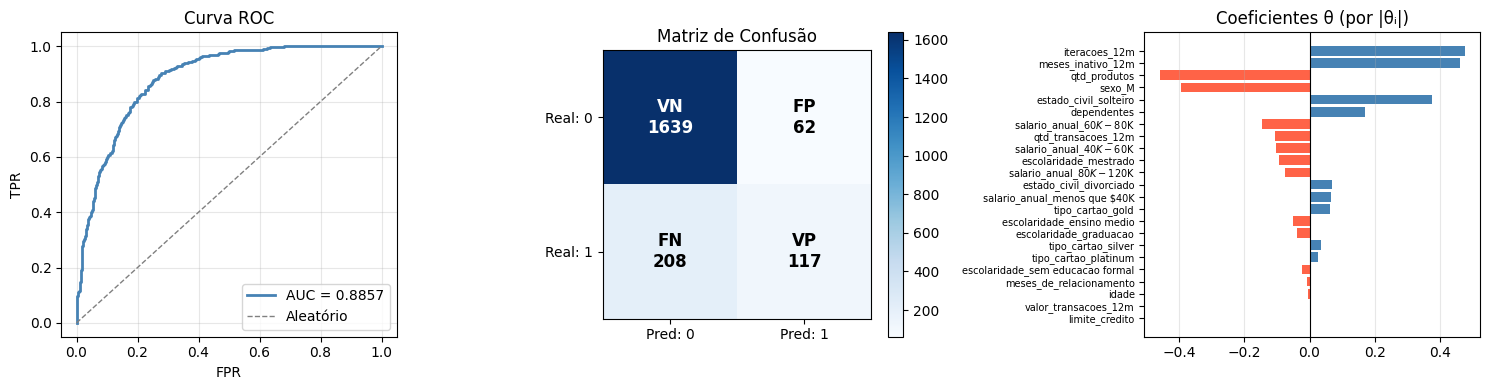

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

y_pred = modelo_newton.predict(X_test)
prob   = modelo_newton.predict_prob(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, prob)

print("=" * 40)
print(f"{'Acurácia':<20} {acc:.4f}")
print(f"{'Precisão':<20} {prec:.4f}")
print(f"{'Recall':<20} {rec:.4f}")
print(f"{'F1-score':<20} {f1:.4f}")
print(f"{'AUC-ROC':<20} {auc:.4f}")
print("=" * 40)

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ROC
taxas_fp, taxas_vp, _ = roc_curve(y_test, prob)
axes[0].plot(taxas_fp, taxas_vp, color='steelblue', linewidth=2, label=f'AUC = {auc:.4f}')
axes[0].plot([0,1],[0,1], 'gray', linestyle='--', linewidth=1, label='Aleatório')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
VN, FP, FN, VP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
valores = np.array([[VN, FP], [FN, VP]])
rotulos = [['VN','FP'],['FN','VP']]
im = axes[1].imshow(valores, cmap='Blues')
for i in range(2):
    for j in range(2):
        cor = 'white' if valores[i,j] > valores.max()/2 else 'black'
        axes[1].text(j, i, f'{rotulos[i][j]}\n{valores[i,j]}', ha='center', va='center',
                     fontsize=12, fontweight='bold', color=cor)
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xticklabels(['Pred: 0','Pred: 1']); axes[1].set_yticklabels(['Real: 0','Real: 1'])
axes[1].set_title('Matriz de Confusão'); plt.colorbar(im, ax=axes[1])

# Coeficientes
coef = modelo_newton.w[1:]
nomes_features = list(X_train.columns)
idx  = np.argsort(np.abs(coef))
cores = ['tomato' if v < 0 else 'steelblue' for v in coef[idx]]
axes[2].barh(range(len(coef)), coef[idx], color=cores)
axes[2].set_yticks(range(len(coef)))
axes[2].set_yticklabels([nomes_features[i] for i in idx], fontsize=7)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Coeficientes θ (por |θᵢ|)'); axes[2].grid(True, axis='x', alpha=0.3)

plt.tight_layout(); plt.show()

In [18]:
(y == 0).sum()
(y == 1).sum()

1627